# 🧠 SignSense AI — Model Training Pipeline
### LSTM Gesture Classifier | 10 ASL Signs | 45,000 Frames
---
**Input:** `MP_Data/` — landmark sequences from `01_data_collection.ipynb`  
**Output:** `signsense_model.keras` + `labels.json` — ready for the FastAPI backend

| Cell | Purpose |
|------|---------|
| 1 | Verify environment |
| 2 | Imports |
| 3 | Configuration |
| 4 | Load dataset from .npy files |
| 5 | Train / Validation / Test split (80/10/10) |
| 6 | Build LSTM model |
| 7 | Train model |
| 8 | Training curves (accuracy/loss) |
| 9 | Evaluate on test set + confusion matrix |
| 10 | Save model + labels for deployment |


## ✅ Cell 1 — Verify Environment

In [2]:
!pip install -U seaborn

In [1]:
import sys
import importlib

print("=" * 60)
print("  SignSense AI — Training Environment Check")
print("=" * 60)
print(f"  Python : {sys.version.split()[0]}")
print()

REQUIRED = ["numpy", "tensorflow", "sklearn", "matplotlib", "seaborn"]
all_ok = True
for module in REQUIRED:
    try:
        mod = importlib.import_module(module)
        ver = getattr(mod, "__version__", "unknown")
        print(f"  ✅  {module:<15} {ver}")
    except ImportError:
        print(f"  ❌  {module:<15} NOT INSTALLED")
        all_ok = False

if not all_ok:
    print()
    print("  Run in terminal (with venv active):")
    print("  pip install seaborn")
print()
print("  🎉  Ready." if all_ok else "  ⚠️  Install missing packages above.")
print("=" * 60)


  SignSense AI — Training Environment Check
  Python : 3.10.11

  ✅  numpy           1.26.4
  ✅  tensorflow      2.18.0
  ✅  sklearn         1.7.2
  ✅  matplotlib      3.10.9
  ✅  seaborn         0.13.2

  🎉  Ready.


## 📚 Cell 2 — Imports

In [4]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics         import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models     import Sequential
from tensorflow.keras.layers     import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks  import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils      import to_categorical
from tensorflow.keras.optimizers import Adam

print("=" * 60)
print(f"  TensorFlow : {tf.__version__}")
print(f"  GPU available : {len(tf.config.list_physical_devices('GPU')) > 0}")
print("  (CPU is fine for this model size — no GPU required)")
print("=" * 60)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


  TensorFlow : 2.18.0
  GPU available : False
  (CPU is fine for this model size — no GPU required)


## ⚙️ Cell 3 — Configuration
> Must match the values used in `01_data_collection.ipynb`.


In [6]:
# ╔══════════════════════════════════════════════════════════╗
# ║              SIGNSENSE AI — TRAINING CONFIG               ║
# ╚══════════════════════════════════════════════════════════╝

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_DIR = r"D:\Downloads\data_collection"
DATA_PATH   = os.path.join(PROJECT_DIR, "MP_Data")
MODEL_DIR   = os.path.join(PROJECT_DIR, "trained_model")
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Must match data collection exactly ────────────────────────────────────────
ASL_ACTIONS = np.array([
    "hello", "thank_you", "please", "yes", "no",
    "sorry", "help", "good", "bad", "stop"
])
NO_SEQUENCES    = 150
SEQUENCE_LENGTH = 30
FEATURE_SIZE    = 1662

# ── Split ratios (80/10/10) ───────────────────────────────────────────────────
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

# ── Training hyperparameters ──────────────────────────────────────────────────
BATCH_SIZE    = 32
MAX_EPOCHS    = 150          # EarlyStopping will likely stop well before this
LEARNING_RATE = 0.001
SEED          = 42

print("=" * 60)
print("  Training Configuration")
print("=" * 60)
print(f"  Classes          : {len(ASL_ACTIONS)}  →  {list(ASL_ACTIONS)}")
print(f"  Sequences/class  : {NO_SEQUENCES}")
print(f"  Total sequences  : {len(ASL_ACTIONS) * NO_SEQUENCES}")
print(f"  Split            : {int(TRAIN_RATIO*100)}% train / {int(VAL_RATIO*100)}% val / {int(TEST_RATIO*100)}% test")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  Max epochs       : {MAX_EPOCHS} (early stopping enabled)")
print(f"  Data path        : {DATA_PATH}")
print(f"  Model save path  : {MODEL_DIR}")
print("=" * 60)

if not os.path.exists(DATA_PATH):
    print(f"  ❌  DATA_PATH not found: {DATA_PATH}")
else:
    print(f"  ✅  Dataset folder found.")


  Training Configuration
  Classes          : 10  →  ['hello', 'thank_you', 'please', 'yes', 'no', 'sorry', 'help', 'good', 'bad', 'stop']
  Sequences/class  : 150
  Total sequences  : 1500
  Split            : 80% train / 10% val / 10% test
  Batch size       : 32
  Max epochs       : 150 (early stopping enabled)
  Data path        : D:\Downloads\data_collection\MP_Data
  Model save path  : D:\Downloads\data_collection\trained_model
  ✅  Dataset folder found.


## 📂 Cell 4 — Load Dataset
Loads all `.npy` landmark sequences into memory as `(samples, 30, 1662)` arrays.

In [7]:
print("Loading dataset from disk...")
print()

label_map = {label: idx for idx, label in enumerate(ASL_ACTIONS)}

sequences, labels = [], []
load_errors = 0

for action in ASL_ACTIONS:
    action_path = os.path.join(DATA_PATH, action)

    for seq_idx in range(NO_SEQUENCES):
        seq_path = os.path.join(action_path, str(seq_idx))
        window = []

        for frame_idx in range(SEQUENCE_LENGTH):
            npy_file = os.path.join(seq_path, f"{frame_idx}.npy")
            try:
                res = np.load(npy_file)
                if res.shape[0] != FEATURE_SIZE:
                    res = np.zeros(FEATURE_SIZE)  # Safety fallback
                window.append(res)
            except Exception:
                window.append(np.zeros(FEATURE_SIZE))
                load_errors += 1

        sequences.append(window)
        labels.append(label_map[action])

    print(f"  ✅  Loaded '{action}'  →  {NO_SEQUENCES} sequences")

X = np.array(sequences)   # shape: (1500, 30, 1662)
y = to_categorical(labels, num_classes=len(ASL_ACTIONS)).astype(int)

print()
print("=" * 60)
print(f"  Dataset loaded successfully")
print("=" * 60)
print(f"  X shape   : {X.shape}   (samples, frames, features)")
print(f"  y shape   : {y.shape}   (samples, classes)")
print(f"  Load errors (frames replaced with zeros) : {load_errors}")
print(f"  Memory usage : ~{X.nbytes / (1024**2):.1f} MB")
print("=" * 60)


Loading dataset from disk...

  ✅  Loaded 'hello'  →  150 sequences
  ✅  Loaded 'thank_you'  →  150 sequences
  ✅  Loaded 'please'  →  150 sequences
  ✅  Loaded 'yes'  →  150 sequences
  ✅  Loaded 'no'  →  150 sequences
  ✅  Loaded 'sorry'  →  150 sequences
  ✅  Loaded 'help'  →  150 sequences
  ✅  Loaded 'good'  →  150 sequences
  ✅  Loaded 'bad'  →  150 sequences
  ✅  Loaded 'stop'  →  150 sequences

  Dataset loaded successfully
  X shape   : (1500, 30, 1662)   (samples, frames, features)
  y shape   : (1500, 10)   (samples, classes)
  Load errors (frames replaced with zeros) : 0
  Memory usage : ~570.6 MB


## 🔀 Cell 5 — Train / Validation / Test Split (80/10/10)
Stratified split — ensures every class is proportionally represented in all 3 sets.

In [8]:
# ── Step 1: Split off test set (10%) ────────────────────────────────────────
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=y    # Ensures balanced classes across split
)

# ── Step 2: Split remaining 90% into train (80%) / val (10%) ────────────────
# val_ratio relative to the 90% remaining = 0.10 / 0.90
val_size_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=val_size_adjusted,
    random_state=SEED,
    stratify=y_train_val
)

print("=" * 60)
print("  Dataset Split Summary")
print("=" * 60)
print(f"  Train      : {X_train.shape[0]:>4} sequences  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation : {X_val.shape[0]:>4} sequences  ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test       : {X_test.shape[0]:>4} sequences  ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Total      : {len(X):>4} sequences")
print("=" * 60)

# Verify class balance across splits
print()
print("  Class balance check (samples per class):")
for split_name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = np.argmax(y_split, axis=1)
    dist   = [np.sum(counts == i) for i in range(len(ASL_ACTIONS))]
    print(f"    {split_name:<10}: {dist}")


  Dataset Split Summary
  Train      : 1200 sequences  (80.0%)
  Validation :  150 sequences  (10.0%)
  Test       :  150 sequences  (10.0%)
  Total      : 1500 sequences

  Class balance check (samples per class):
    Train     : [120, 120, 120, 120, 120, 120, 120, 120, 120, 120]
    Val       : [15, 15, 15, 15, 15, 15, 15, 15, 15, 15]
    Test      : [15, 15, 15, 15, 15, 15, 15, 15, 15, 15]


## 🏗️ Cell 6 — Build LSTM Model

**Architecture rationale:**
- 3 stacked LSTM layers capture short → mid → long-term temporal gesture patterns
- `BatchNormalization` after each LSTM stabilizes training, allows higher learning rate
- `Dropout` (0.3–0.4) prevents overfitting — important since 150 seq/class is moderate-sized data
- Dense layers narrow down to final classification with softmax over 10 classes


In [9]:
model = Sequential(name="SignSense_LSTM")

# ── Input: (30 frames, 1662 features) ───────────────────────────────────────
model.add(LSTM(64, return_sequences=True, activation="tanh",
               input_shape=(SEQUENCE_LENGTH, FEATURE_SIZE), name="lstm_1"))
model.add(BatchNormalization(name="bn_1"))
model.add(Dropout(0.3, name="dropout_1"))

model.add(LSTM(128, return_sequences=True, activation="tanh", name="lstm_2"))
model.add(BatchNormalization(name="bn_2"))
model.add(Dropout(0.4, name="dropout_2"))

model.add(LSTM(64, return_sequences=False, activation="tanh", name="lstm_3"))
model.add(BatchNormalization(name="bn_3"))
model.add(Dropout(0.3, name="dropout_3"))

model.add(Dense(64, activation="relu", name="dense_1"))
model.add(Dropout(0.2, name="dropout_4"))

model.add(Dense(32, activation="relu", name="dense_2"))

model.add(Dense(len(ASL_ACTIONS), activation="softmax", name="output"))

# ── Compile ───────────────────────────────────────────────────────────────────
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["categorical_accuracy"]
)

print("=" * 60)
print("  SignSense LSTM — Model Architecture")
print("=" * 60)
model.summary()

total_params = model.count_params()
print()
print(f"  Total parameters : {total_params:,}")
print(f"  Output classes   : {len(ASL_ACTIONS)}")
print("=" * 60)


  SignSense LSTM — Model Architecture


Model: "SignSense_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │       442,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 30, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 30, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 597,930 (2.28 MB)

 Trainable params: 597,418 (2.28 MB)

 Non-trainable params: 512 (2.00 KB)


  Total parameters : 597,930
  Output classes   : 10


## 🚀 Cell 7 — Train the Model

**Callbacks used:**
- `EarlyStopping` — stops training when validation loss stops improving (patience=20), restores best weights
- `ReduceLROnPlateau` — halves learning rate if validation loss plateaus
- `ModelCheckpoint` — saves the best model automatically during training

⏱️ Expected time on CPU: **5–12 minutes** for this dataset size.


In [12]:
checkpoint_path = os.path.join(MODEL_DIR, "best_model.keras")

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=0
    )
]

print("=" * 60)
print("  Training Started")
print("=" * 60)
print(f"  Train samples : {len(X_train)}")
print(f"  Val samples   : {len(X_val)}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Max epochs    : {MAX_EPOCHS} (early stopping active)")
print("=" * 60)
print()

import time
train_start = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

train_time = time.time() - train_start

print()
print("=" * 60)
print(f"  Training Complete — {train_time/60:.1f} minutes")
print("=" * 60)
print(f"  Epochs run        : {len(history.history['loss'])}")
print(f"  Best val_loss      : {min(history.history['val_loss']):.4f}")
print(f"  Best val_accuracy  : {max(history.history['val_categorical_accuracy']):.4f}")
print("=" * 60)


  Training Started
  Train samples : 1200
  Val samples   : 150
  Batch size    : 32
  Max epochs    : 150 (early stopping active)

Epoch 1/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - categorical_accuracy: 0.2625 - loss: 1.9713 - val_categorical_accuracy: 0.1600 - val_loss: 2.1641 - learning_rate: 0.0010
Epoch 2/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - categorical_accuracy: 0.4367 - loss: 1.4503 - val_categorical_accuracy: 0.2200 - val_loss: 1.9947 - learning_rate: 0.0010
Epoch 3/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - categorical_accuracy: 0.5408 - loss: 1.2219 - val_categorical_accuracy: 0.2333 - val_loss: 1.9085 - learning_rate: 0.0010
Epoch 4/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - categorical_accuracy: 0.6308 - loss: 1.0633 - val_categorical_accuracy: 0.5200 - val_loss: 1.5966 - learning_rate: 0.0010
Epoch 5/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - categorical_accuracy: 0.6317 - loss: 0.9786 - val_categorical_accuracy: 0.4267 - val_loss: 1.5882 - learning

## 📈 Cell 8 — Training Curves
Visualize accuracy and loss over epochs to check for overfitting.

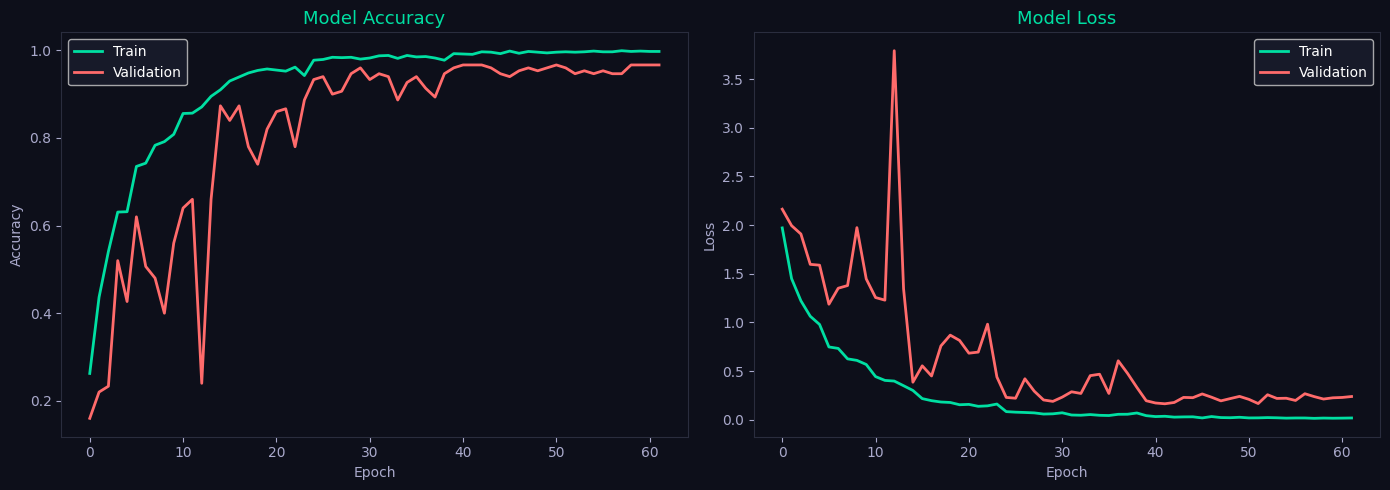

📊 Chart saved: D:\Downloads\data_collection\trained_model\training_curves.png

  Overfitting Diagnostic
  Final train accuracy : 0.9975
  Final val accuracy   : 0.9667
  Gap                  : 0.0308
  ✅  Healthy gap — model is generalizing well.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0d0f1a")

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#0d0f1a")
ax1.plot(history.history["categorical_accuracy"], color="#00dfa2", linewidth=2, label="Train")
ax1.plot(history.history["val_categorical_accuracy"], color="#ff6b6b", linewidth=2, label="Validation")
ax1.set_title("Model Accuracy", color="#00dfa2", fontsize=13)
ax1.set_xlabel("Epoch", color="#aaaacc")
ax1.set_ylabel("Accuracy", color="#aaaacc")
ax1.tick_params(colors="#aaaacc")
ax1.legend(facecolor="#1a1d2e", labelcolor="white")
for spine in ax1.spines.values(): spine.set_edgecolor("#2a2d3e")

# ── Loss ──────────────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#0d0f1a")
ax2.plot(history.history["loss"], color="#00dfa2", linewidth=2, label="Train")
ax2.plot(history.history["val_loss"], color="#ff6b6b", linewidth=2, label="Validation")
ax2.set_title("Model Loss", color="#00dfa2", fontsize=13)
ax2.set_xlabel("Epoch", color="#aaaacc")
ax2.set_ylabel("Loss", color="#aaaacc")
ax2.tick_params(colors="#aaaacc")
ax2.legend(facecolor="#1a1d2e", labelcolor="white")
for spine in ax2.spines.values(): spine.set_edgecolor("#2a2d3e")

plt.tight_layout()
chart_path = os.path.join(MODEL_DIR, "training_curves.png")
plt.savefig(chart_path, dpi=120, facecolor="#0d0f1a")
plt.show()

print(f"📊 Chart saved: {chart_path}")
print()

# ── Overfitting diagnostic ───────────────────────────────────────────────────
final_train_acc = history.history["categorical_accuracy"][-1]
final_val_acc   = history.history["val_categorical_accuracy"][-1]
gap = final_train_acc - final_val_acc

print("=" * 60)
print("  Overfitting Diagnostic")
print("=" * 60)
print(f"  Final train accuracy : {final_train_acc:.4f}")
print(f"  Final val accuracy   : {final_val_acc:.4f}")
print(f"  Gap                  : {gap:.4f}")
if gap > 0.15:
    print("  ⚠️  Noticeable gap — model may be overfitting slightly.")
    print("      Consider: more data, stronger dropout, or fewer epochs.")
else:
    print("  ✅  Healthy gap — model is generalizing well.")
print("=" * 60)


## 🎯 Cell 9 — Evaluate on Test Set
Final unbiased evaluation + confusion matrix + per-class precision/recall.

  Test Set Performance (Unseen Data)
  Test Loss     : 0.2744
  Test Accuracy : 0.9333  (93.3%)

  Per-Class Performance:
              precision    recall  f1-score   support

       hello      0.833     1.000     0.909        15
   thank_you      1.000     0.867     0.929        15
      please      1.000     0.933     0.966        15
         yes      0.882     1.000     0.938        15
          no      1.000     0.800     0.889        15
       sorry      0.938     1.000     0.968        15
        help      1.000     1.000     1.000        15
        good      0.867     0.867     0.867        15
         bad      0.867     0.867     0.867        15
        stop      1.000     1.000     1.000        15

    accuracy                          0.933       150
   macro avg      0.939     0.933     0.933       150
weighted avg      0.939     0.933     0.933       150



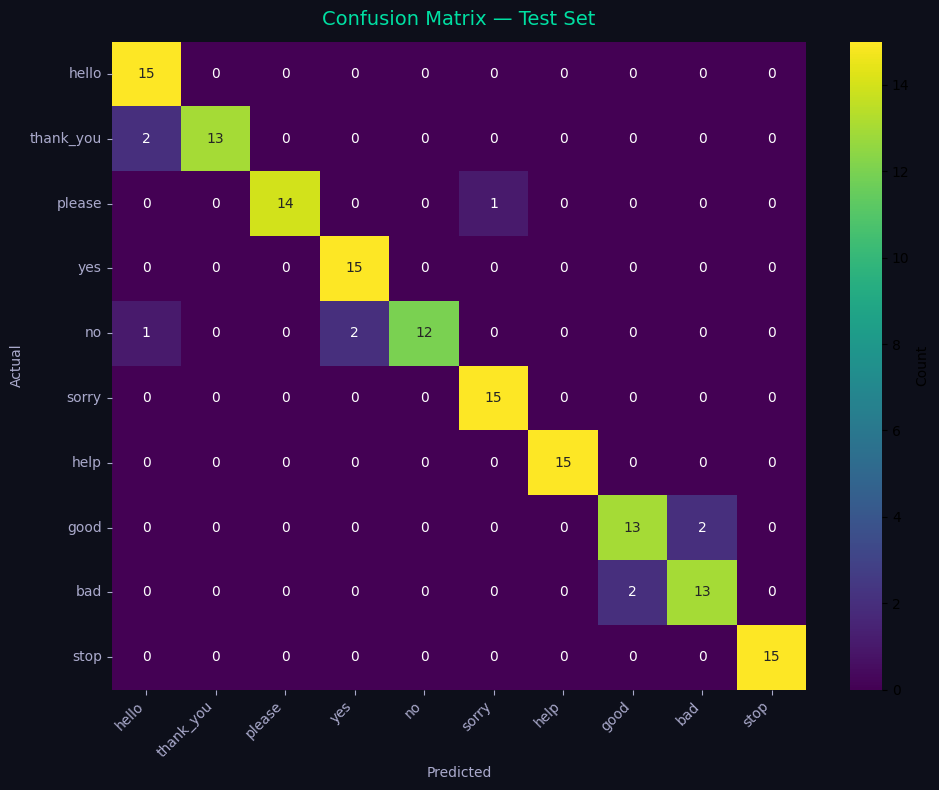

📊 Confusion matrix saved: D:\Downloads\data_collection\trained_model\confusion_matrix.png

  Avg prediction confidence : 0.987
  Min prediction confidence : 0.515


In [14]:
# ── Test set evaluation ───────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("=" * 60)
print("  Test Set Performance (Unseen Data)")
print("=" * 60)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.1f}%)")
print("=" * 60)

# ── Predictions ───────────────────────────────────────────────────────────────
y_pred_probs = model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = np.argmax(y_test, axis=1)

# ── Classification report ───────────────────────────────────────────────────
print()
print("  Per-Class Performance:")
print(classification_report(y_true, y_pred, target_names=ASL_ACTIONS, digits=3))

# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("#0d0f1a")
sns.heatmap(
    cm, annot=True, fmt="d", cmap="viridis",
    xticklabels=ASL_ACTIONS, yticklabels=ASL_ACTIONS,
    ax=ax, cbar_kws={"label": "Count"}
)
ax.set_facecolor("#0d0f1a")
ax.set_title("Confusion Matrix — Test Set", color="#00dfa2", fontsize=14, pad=12)
ax.set_xlabel("Predicted", color="#aaaacc")
ax.set_ylabel("Actual", color="#aaaacc")
ax.tick_params(colors="#aaaacc")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = os.path.join(MODEL_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=120, facecolor="#0d0f1a")
plt.show()

print(f"📊 Confusion matrix saved: {cm_path}")

# ── Confidence distribution check ───────────────────────────────────────────
confidences = np.max(y_pred_probs, axis=1)
print()
print(f"  Avg prediction confidence : {np.mean(confidences):.3f}")
print(f"  Min prediction confidence : {np.min(confidences):.3f}")


## 💾 Cell 10 — Save Model for Deployment
Saves the final model + label mapping needed by the FastAPI backend.

In [15]:
# ── Save final model (best weights already restored via EarlyStopping) ───────
final_model_path = os.path.join(MODEL_DIR, "signsense_model.keras")
model.save(final_model_path)

# ── Save label mapping ───────────────────────────────────────────────────────
labels_path = os.path.join(MODEL_DIR, "labels.json")
labels_data = {
    "actions": list(ASL_ACTIONS),
    "label_map": {str(idx): label for idx, label in enumerate(ASL_ACTIONS)},
    "sequence_length": SEQUENCE_LENGTH,
    "feature_size": FEATURE_SIZE,
    "test_accuracy": float(test_acc),
    "test_loss": float(test_loss)
}
with open(labels_path, "w") as f:
    json.dump(labels_data, f, indent=2)

# ── Save training metadata ───────────────────────────────────────────────────
metadata_path = os.path.join(MODEL_DIR, "training_metadata.json")
metadata = {
    "classes": list(ASL_ACTIONS),
    "num_classes": len(ASL_ACTIONS),
    "sequences_per_class": NO_SEQUENCES,
    "sequence_length": SEQUENCE_LENGTH,
    "feature_size": FEATURE_SIZE,
    "train_samples": int(len(X_train)),
    "val_samples": int(len(X_val)),
    "test_samples": int(len(X_test)),
    "epochs_trained": len(history.history["loss"]),
    "final_train_accuracy": float(history.history["categorical_accuracy"][-1]),
    "final_val_accuracy": float(history.history["val_categorical_accuracy"][-1]),
    "test_accuracy": float(test_acc),
    "test_loss": float(test_loss),
    "total_parameters": int(model.count_params())
}
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("=" * 60)
print("  ✅  Model Saved Successfully")
print("=" * 60)
print(f"  Model file     : {final_model_path}")
print(f"  Labels file    : {labels_path}")
print(f"  Metadata file  : {metadata_path}")
print("=" * 60)
print()
print(f"  Final test accuracy : {test_acc*100:.1f}%")
print()
print("  📂 Your trained_model/ folder now contains:")
for f in sorted(os.listdir(MODEL_DIR)):
    fpath = os.path.join(MODEL_DIR, f)
    size  = os.path.getsize(fpath) / 1024
    print(f"     • {f}  ({size:.1f} KB)")
print()
print("  ▶️  Next step: backend/main.py (FastAPI server)")
print("     This will load signsense_model.keras and expose a /predict endpoint.")


  ✅  Model Saved Successfully
  Model file     : D:\Downloads\data_collection\trained_model\signsense_model.keras
  Labels file    : D:\Downloads\data_collection\trained_model\labels.json
  Metadata file  : D:\Downloads\data_collection\trained_model\training_metadata.json

  Final test accuracy : 93.3%

  📂 Your trained_model/ folder now contains:
     • best_model.keras  (7078.4 KB)
     • confusion_matrix.png  (55.6 KB)
     • labels.json  (0.5 KB)
     • signsense_model.keras  (7078.4 KB)
     • training_curves.png  (84.0 KB)
     • training_metadata.json  (0.5 KB)

  ▶️  Next step: backend/main.py (FastAPI server)
     This will load signsense_model.keras and expose a /predict endpoint.
